In [2]:
# Hierarchical Clustering

# In this notebook we will see how hierarchical (agglomerative) clustering works on a small, easy-to-visualise dataset.

# The idea in 4 lines
# Start with every point as its own cluster.
# Find the two closest clusters and merge them.
# Repeat step 2 until only one big cluster is left.
# Draw the merges as a tree → that tree is called a dendrogram.
# We then cut the dendrogram horizontally at some height to decide our final K (number of clusters).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scipy — only for the dendrogram picture
from scipy.cluster.hierarchy import linkage, dendrogram

# sklearn — the actual clustering algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [8]:
# Load the data

df = pd.read_csv(r"C:\Users\onc\Downloads\iris_sample.csv")
print('Shape:', df.shape)
df

Shape: (21, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,4.3,3.0,1.1,0.1,setosa
1,5.1,3.4,1.5,0.2,setosa
2,4.8,3.1,1.6,0.2,setosa
3,4.8,3.0,1.4,0.3,setosa
4,5.1,3.5,1.4,0.3,setosa
5,5.3,3.7,1.5,0.2,setosa
6,5.0,3.4,1.6,0.4,setosa
7,6.1,2.9,4.7,1.4,versicolor
8,5.5,2.5,4.0,1.3,versicolor
9,5.5,2.4,3.8,1.1,versicolor


In [ ]:
 # Pick features and scale them

# We use only petal_length and petal_width so we can plot everything in 2D.

# Note: clustering is unsupervised, so we drop the species column before clustering. We will only use species at the end to check how well clustering matched reality.

# Hierarchical clustering uses distance, so features must be on the same scale. We use StandardScaler (mean 0, std 1).



In [9]:
X = df[['petal_length', 'petal_width']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Original first 3 rows:\n', X[:3])
print('\nScaled first 3 rows:\n', X_scaled[:3].round(2))

Original first 3 rows:
 [[1.1 0.1]
 [1.5 0.2]
 [1.6 0.2]]

Scaled first 3 rows:
 [[-1.47 -1.41]
 [-1.24 -1.28]
 [-1.19 -1.28]]


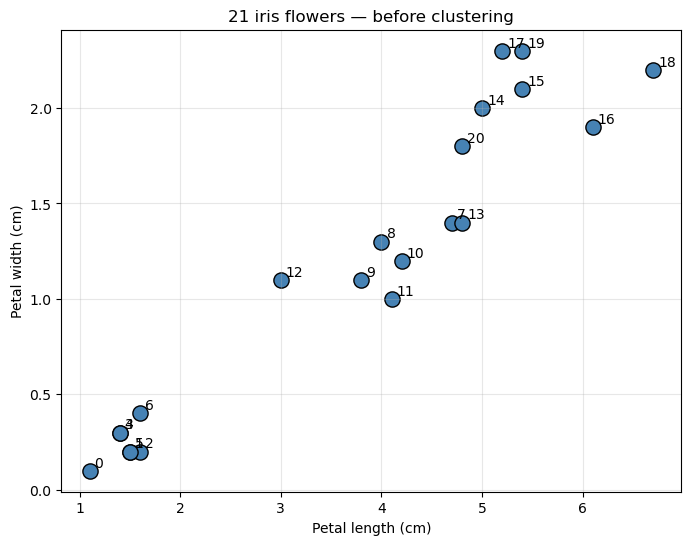

In [10]:
 # Look at the raw data first

# Each point is labelled with its row index so we can spot it again in the dendrogram.

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=120, c='steelblue', edgecolor='black')

for i in range(len(X)):
    plt.text(X[i, 0] + 0.05, X[i, 1] + 0.02, str(i), fontsize=10)

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('21 iris flowers — before clustering')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Draw the dendrogram to decide K

# How to read the dendrogram:

# The x-axis shows the points (or groups of points).
# The y-axis is the distance at which two clusters were merged.
# A short bar = merged early = points are very similar.
# A tall bar = merged late = clusters were far apart.
# Rule of thumb to pick K: find the tallest vertical gap that no horizontal merge crosses, and draw a horizontal line through it. The number of vertical lines it crosses = K.


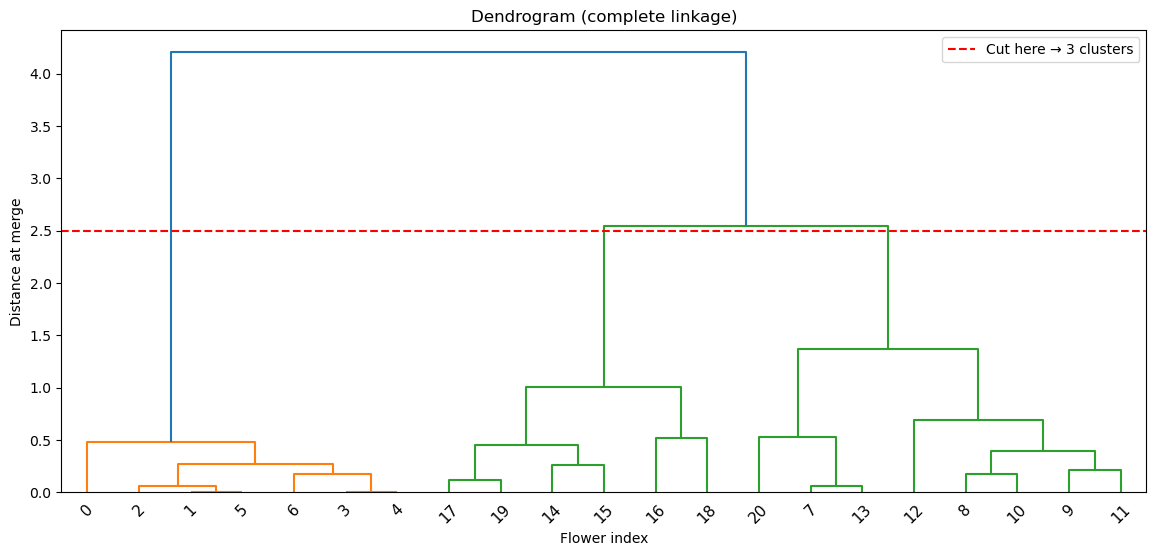

From the dendrogram we decide K = 3


In [20]:
# linkage() runs the whole agglomerative algorithm and returns a merge matrix
Z = linkage(X_scaled, method='complete')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=[str(i) for i in range(len(X_scaled))],
    leaf_font_size=11,
)
plt.axhline(y=2.5, color='red', linestyle='--', label='Cut here → 3 clusters')
plt.title('Dendrogram (complete linkage)')
plt.xlabel('Flower index')
plt.ylabel('Distance at merge')
plt.legend()
plt.show()

print('From the dendrogram we decide K = 3')

In [15]:
# Fit Hierarchical Clustering with sklearn

# Important parameters:

# n_clusters=3 — how many clusters we want (we picked this from the dendrogram).
# linkage='ward,complete,singleor average' — same linkage method we used in the dendrogram, so results match.
# metric='euclidean' — distance metric (ward only works with euclidean).
# fit_predict does two things at once: trains the model and returns the cluster label for every point.

In [21]:
hc = AgglomerativeClustering(n_clusters=3, linkage='complete', metric='euclidean')
labels = hc.fit_predict(X_scaled)

print('Cluster label for each of the 21 flowers:')
print(labels)

Cluster label for each of the 21 flowers:
[1 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 0]


In [22]:
# Attach the labels back to the dataframe

df['cluster'] = labels
df

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,4.3,3.0,1.1,0.1,setosa,1
1,5.1,3.4,1.5,0.2,setosa,1
2,4.8,3.1,1.6,0.2,setosa,1
3,4.8,3.0,1.4,0.3,setosa,1
4,5.1,3.5,1.4,0.3,setosa,1
5,5.3,3.7,1.5,0.2,setosa,1
6,5.0,3.4,1.6,0.4,setosa,1
7,6.1,2.9,4.7,1.4,versicolor,0
8,5.5,2.5,4.0,1.3,versicolor,0
9,5.5,2.4,3.8,1.1,versicolor,0


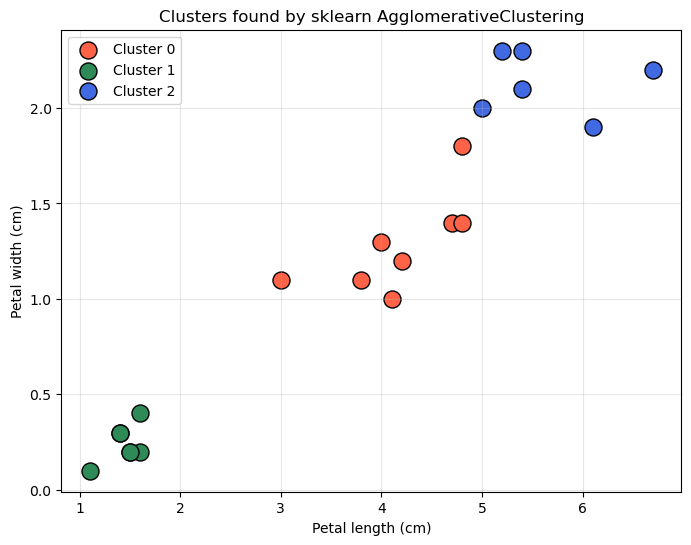

In [23]:
# Plot the final clusters
plt.figure(figsize=(8, 6))
colors = ['tomato', 'seagreen', 'royalblue']

for c in np.unique(labels):
    mask = labels == c
    plt.scatter(X[mask, 0], X[mask, 1],
                s=150, c=colors[c], edgecolor='black',
                label=f'Cluster {c}')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Clusters found by sklearn AgglomerativeClustering')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Did clustering match the real species?
# Since the CSV already has true species labels,
# we can peek at how well our unsupervised clusters line up with reality. 
#     Each row should ideally have all 7 flowers in a single column.

In [19]:
pd.crosstab(df['species'], df['cluster'],
            rownames=['true species'], colnames=['cluster'])

cluster,0,1,2
true species,,,
setosa,0,7,0
versicolor,0,0,7
virginica,7,0,0
